In [1]:
import sys, os
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))
os.chdir(Path.cwd().parent.parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

import warnings
warnings.filterwarnings('ignore')

print(f"Working directory: {os.getcwd()}")

from thesis.config import Config
from thesis.data.rekis import ReKISSource

cfg = Config()
src = ReKISSource(cfg)

# Load full 63-year record
print("Loading ReKIS data (1961-2023)...")
df = src.load(cfg.date_start, cfg.date_end, exclude_holdout=False)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
print(f"Loaded {len(df):,} rows, {df['station_id'].nunique()} stations")


# Station metadata: one row per station
stations = df.groupby('station_id').agg(
    lon=('lon', 'first'),
    lat=('lat', 'first'),
    elevation_m=('elevation_m', 'first'),
).reset_index()

# Annual mean precipitation per station (mm/year)
annual = df.groupby(['station_id', 'year'])['precip_mm'].sum().reset_index()
annual_mean = annual.groupby('station_id')['precip_mm'].mean().reset_index()
annual_mean.columns = ['station_id', 'annual_precip_mm']

# Monthly climatological mean per station
monthly_clim = df.groupby(['station_id', 'month'])['precip_mm'].mean().reset_index()
monthly_clim.columns = ['station_id', 'month', 'monthly_mean_mm']

# Merge
stations = stations.merge(annual_mean, on='station_id')

print(f"Stations: {len(stations)}")
print(f"Annual precip range: {stations['annual_precip_mm'].min():.0f} – {stations['annual_precip_mm'].max():.0f} mm")
print(f"Elevation range: {stations['elevation_m'].min():.0f} – {stations['elevation_m'].max():.0f} m")
stations.describe().round(2)

Working directory: /Users/etomengoi/Desktop/precip_interpolation_thesis
Loading ReKIS data (1961-2023)...
Loaded 56,558,580 rows, 2458 stations
Stations: 2458
Annual precip range: 413 – 1762 mm
Elevation range: -12 – 1410 m


,lon,lat,elevation_m,annual_precip_mm
count,2458.00,2458.00,2458.00,2458.00
mean,12.21,51.62,228.71,676.99
std,1.62,0.97,201.38,167.05
min,9.53,50.08,-12.00,412.58
25%,10.86,50.81,68.00,564.34
50%,12.01,51.49,164.00,631.83
75%,13.50,52.34,335.00,739.47
max,15.82,53.71,1410.00,1761.88


## Map: annual precipitation normals across the study area

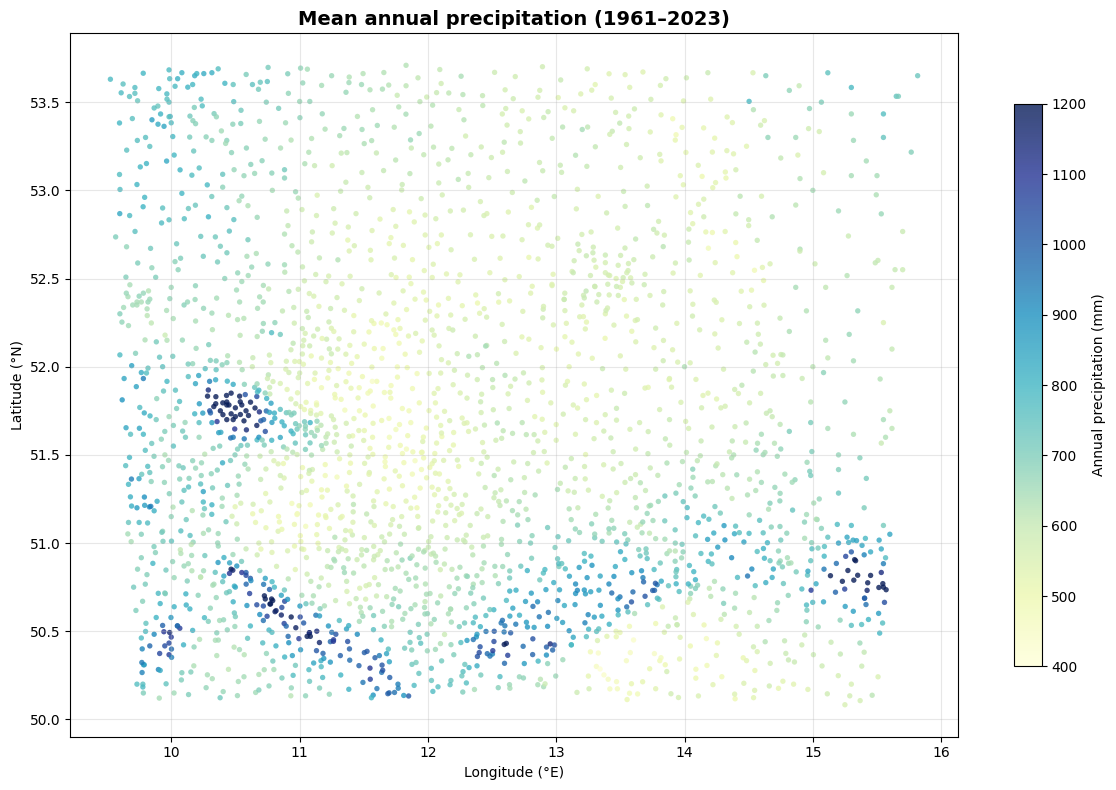

In [2]:
fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    stations['lon'], stations['lat'],
    c=stations['annual_precip_mm'], cmap='YlGnBu',
    s=15, edgecolors='none', alpha=0.8,
    vmin=400, vmax=1200,
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8, label='Annual precipitation (mm)')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('Mean annual precipitation (1961–2023)', fontsize=14, fontweight='bold')
ax.set_aspect('auto')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

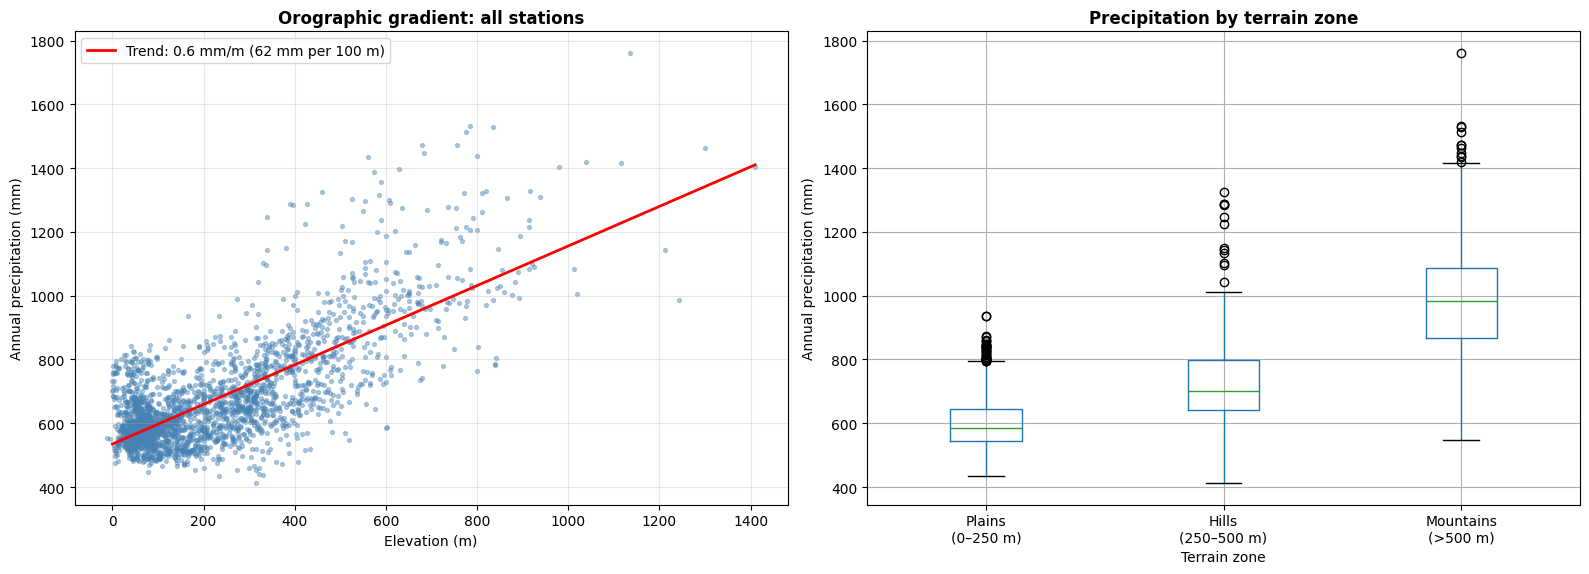

Plains
(0–250 m): n=1533, mean elev=102 m, mean precip=602 mm/yr, median=585 mm/yr
Hills
(250–500 m): n=660, mean elev=354 m, mean precip=723 mm/yr, median=702 mm/yr
Mountains
(>500 m): n=261, mean elev=662 m, mean precip=1000 mm/yr, median=982 mm/yr


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
ax.scatter(stations['elevation_m'], stations['annual_precip_mm'],
           s=8, alpha=0.4, c='steelblue')

z = np.polyfit(stations['elevation_m'], stations['annual_precip_mm'], 1)
p = np.poly1d(z)
elev_range = np.linspace(0, stations['elevation_m'].max(), 100)
ax.plot(elev_range, p(elev_range), 'r-', lw=2,
        label=f'Trend: {z[0]:.1f} mm/m ({z[0]*100:.0f} mm per 100 m)')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Annual precipitation (mm)')
ax.set_title('Orographic gradient: all stations', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

stations['terrain'] = pd.cut(
    stations['elevation_m'],
    bins=[0, 250, 500, 1500],
    labels=['Plains\n(0–250 m)', 'Hills\n(250–500 m)', 'Mountains\n(>500 m)']
)
stations.boxplot(column='annual_precip_mm', by='terrain', ax=axes[1])
axes[1].set_xlabel('Terrain zone')
axes[1].set_ylabel('Annual precipitation (mm)')
axes[1].set_title('Precipitation by terrain zone', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

for zone, grp in stations.groupby('terrain', observed=True):
    print(f"{zone}: n={len(grp)}, "
          f"mean elev={grp['elevation_m'].mean():.0f} m, "
          f"mean precip={grp['annual_precip_mm'].mean():.0f} mm/yr, "
          f"median={grp['annual_precip_mm'].median():.0f} mm/yr")